# 📹 Video 5: Evaluasi & Perbandingan Model Data Mining

**Mata Kuliah**: Data Mining (21TIF604)  
**Universitas Islam Nahdlatul Ulama Jepara**  
**Dosen**: Ir. Adi Sucipto, M.Kom

---

### Tujuan Video Ini:
1. Menjalankan ulang ketiga metode secara ringkas (klasifikasi, clustering, association rules)
2. Membandingkan hasil dan metrik evaluasi dari setiap metode
3. Menjustifikasi pemilihan metode terbaik untuk konteks UMKM Mebel Jepara
4. Menyusun kesimpulan dan rekomendasi akhir

---

### Konteks (Sub-CPMK 3.4 & 3.5):
Mahasiswa dapat menjelaskan proses accuracy dalam menentukan hasil dan memberikan justifikasi pada setiap iterasi.

In [1]:
# ============================================================
# STEP 1: INSTALL LIBRARY & MOUNT GOOGLE DRIVE
# ============================================================
# Kita butuh library dari ketiga metode sekaligus untuk perbandingan
# ============================================================

!pip install mlxtend -q

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Klasifikasi (C4.5 / Decision Tree)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Clustering (K-Means)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Association Rules (Apriori)
from mlxtend.frequent_patterns import apriori, association_rules

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 6)

# Folder kerja di Google Drive
DRIVE_FOLDER = '/content/drive/MyDrive/data-mining'

print("✅ Google Drive ter-mount & semua library berhasil diimport!")
print(f"📁 Folder kerja: {DRIVE_FOLDER}")

Mounted at /content/drive
✅ Google Drive ter-mount & semua library berhasil diimport!
📁 Folder kerja: /content/drive/MyDrive/data-mining


In [2]:
# ============================================================
# STEP 2: LOAD DATA BERSIH HASIL PREPROCESSING (Video 1)
# ============================================================
# File tersimpan di Google Drive
# ============================================================

data_path = os.path.join(DRIVE_FOLDER, 'online_retail_clean.csv')
df = pd.read_csv(data_path)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"✅ Data bersih berhasil dimuat! {len(df):,} baris x {df.shape[1]} kolom")

✅ Data bersih berhasil dimuat! 342,273 baris x 9 kolom


## Step 3: Menjalankan Ulang Ketiga Metode

Untuk perbandingan yang adil, kita jalankan ketiga metode secara ringkas dalam satu notebook.  
Data dan parameter yang digunakan sama dengan video 2, 3, dan 4.

In [3]:
# ============================================================
# METODE 1: KLASIFIKASI — DECISION TREE (C4.5)
# ============================================================
# Ringkasan dari Video 2: klasifikasi loyalitas pelanggan
# ============================================================

print("=" * 70)
print("🔵 METODE 1: KLASIFIKASI — DECISION TREE (C4.5)")
print("=" * 70)

# --- Feature Engineering per pelanggan ---
customer_df = df.groupby('CustomerID').agg(
    total_belanja=('TotalAmount', 'sum'),
    jumlah_transaksi=('InvoiceNo', 'nunique'),
    jumlah_produk=('StockCode', 'nunique'),
    rata_rata_qty=('Quantity', 'mean'),
    rata_rata_belanja=('TotalAmount', 'mean'),
).reset_index()

# --- Buat label loyal/tidak loyal ---
median_transaksi = customer_df['jumlah_transaksi'].median()
customer_df['label_loyal'] = np.where(
    customer_df['jumlah_transaksi'] > median_transaksi, 1, 0
)

# --- Split data ---
fitur = ['total_belanja', 'jumlah_produk', 'rata_rata_qty', 'rata_rata_belanja']
X = customer_df[fitur]
y = customer_df['label_loyal']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Latih model ---
model_dt = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
model_dt.fit(X_train, y_train)

# --- Prediksi & evaluasi ---
y_pred = model_dt.predict(X_test)
akurasi_dt = accuracy_score(y_test, y_pred)

print(f"   Akurasi: {akurasi_dt:.4f} ({akurasi_dt*100:.2f}%)")
print(f"   Kedalaman pohon: {model_dt.get_depth()}")
print(f"   Jumlah daun: {model_dt.get_n_leaves()}")
print(f"   Fitur terpenting: {fitur[np.argmax(model_dt.feature_importances_)]}")

# Simpan hasil untuk perbandingan
hasil_klasifikasi = {
    'Metode': 'Klasifikasi (C4.5)',
    'Metrik Utama': 'Accuracy',
    'Nilai': akurasi_dt,
    'Keterangan': f'Akurasi {akurasi_dt*100:.2f}%, Fitur utama: {fitur[np.argmax(model_dt.feature_importances_)]}'
}

🔵 METODE 1: KLASIFIKASI — DECISION TREE (C4.5)
   Akurasi: 0.8382 (83.82%)
   Kedalaman pohon: 5
   Jumlah daun: 28
   Fitur terpenting: total_belanja


In [4]:
# ============================================================
# METODE 2: CLUSTERING — K-MEANS
# ============================================================
# Ringkasan dari Video 3: segmentasi pelanggan dengan RFM
# ============================================================

print("=" * 70)
print("🟢 METODE 2: CLUSTERING — K-MEANS")
print("=" * 70)

# --- Hitung RFM ---
tanggal_referensi = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df.groupby('CustomerID').agg(
    recency=('InvoiceDate', lambda x: (tanggal_referensi - x.max()).days),
    frequency=('InvoiceNo', 'nunique'),
    monetary=('TotalAmount', 'sum')
).reset_index()

# --- Standarisasi ---
fitur_rfm = ['recency', 'frequency', 'monetary']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm[fitur_rfm])

# --- Tentukan K optimal dengan silhouette ---
best_k = 3  # Default, akan dikonfirmasi
best_score = -1
for k in range(2, 8):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    if score > best_score:
        best_score = score
        best_k = k

# --- Jalankan K-Means final ---
kmeans_final = KMeans(n_clusters=best_k, init='k-means++', n_init=10, random_state=42)
cluster_labels = kmeans_final.fit_predict(X_scaled)
silhouette_final = silhouette_score(X_scaled, cluster_labels)

print(f"   Jumlah cluster optimal (K): {best_k}")
print(f"   Silhouette Score: {silhouette_final:.4f}")
print(f"   Jumlah iterasi konvergen: {kmeans_final.n_iter_}")

# Simpan hasil untuk perbandingan
hasil_clustering = {
    'Metode': 'Clustering (K-Means)',
    'Metrik Utama': 'Silhouette Score',
    'Nilai': silhouette_final,
    'Keterangan': f'K={best_k}, Silhouette={silhouette_final:.4f}'
}

🟢 METODE 2: CLUSTERING — K-MEANS
   Jumlah cluster optimal (K): 4
   Silhouette Score: 0.5805
   Jumlah iterasi konvergen: 7


In [5]:
# ============================================================
# METODE 3: ASSOCIATION RULES — APRIORI
# ============================================================
# Ringkasan dari Video 4: pola pembelian produk
# ============================================================

print("=" * 70)
print("🟡 METODE 3: ASSOCIATION RULES — APRIORI")
print("=" * 70)

# --- Siapkan basket ---
df['Description'] = df['Description'].str.strip()
basket = df.groupby(['InvoiceNo', 'Description'])['Quantity'].sum().unstack().fillna(0)
basket_bool = basket.applymap(lambda x: True if x > 0 else False)

# --- Jalankan Apriori ---
frequent_itemsets = apriori(basket_bool, min_support=0.02, use_colnames=True, verbose=0)

# --- Hasilkan aturan asosiasi ---
rules = association_rules(
    frequent_itemsets, metric='confidence', min_threshold=0.3,
    num_itemsets=len(frequent_itemsets)
)

# --- Filter aturan kuat ---
strong_rules = rules[
    (rules['lift'] > 1) &
    (rules['confidence'] >= 0.4) &
    (rules['support'] >= 0.02)
].sort_values('lift', ascending=False)

# --- Hitung statistik ---
avg_lift = strong_rules['lift'].mean() if len(strong_rules) > 0 else 0
avg_confidence = strong_rules['confidence'].mean() if len(strong_rules) > 0 else 0
max_lift = strong_rules['lift'].max() if len(strong_rules) > 0 else 0

print(f"   Total frequent itemsets: {len(frequent_itemsets):,}")
print(f"   Total aturan asosiasi: {len(rules):,}")
print(f"   Aturan kuat (Lift>1, Conf≥40%, Sup≥2%): {len(strong_rules)}")
print(f"   Rata-rata Lift: {avg_lift:.2f}")
print(f"   Rata-rata Confidence: {avg_confidence:.4f}")
print(f"   Lift tertinggi: {max_lift:.2f}")

# Simpan hasil untuk perbandingan
hasil_association = {
    'Metode': 'Association Rules (Apriori)',
    'Metrik Utama': 'Avg Lift',
    'Nilai': avg_lift,
    'Keterangan': f'{len(strong_rules)} aturan kuat, Avg Lift={avg_lift:.2f}, Max Lift={max_lift:.2f}'
}

🟡 METODE 3: ASSOCIATION RULES — APRIORI
   Total frequent itemsets: 206
   Total aturan asosiasi: 26
   Aturan kuat (Lift>1, Conf≥40%, Sup≥2%): 17
   Rata-rata Lift: 9.31
   Rata-rata Confidence: 0.5178
   Lift tertinggi: 11.77


## Step 4: Tabel Perbandingan Ketiga Metode

Sekarang kita bandingkan ketiga metode secara head-to-head.  
Perlu diingat: **setiap metode punya tujuan berbeda**, jadi perbandingan ini bukan tentang "mana yang lebih baik" secara mutlak, melainkan **mana yang paling cocok untuk masalah tertentu**.

In [6]:
# ============================================================
# TABEL PERBANDINGAN KETIGA METODE
# ============================================================
# Setiap metode punya tujuan dan metrik evaluasi yang berbeda:
# - Klasifikasi: memprediksi label (Accuracy)
# - Clustering: mengelompokkan data (Silhouette Score)
# - Association Rules: menemukan pola (Lift)
# ============================================================

perbandingan = pd.DataFrame([hasil_klasifikasi, hasil_clustering, hasil_association])

print("📋 TABEL PERBANDINGAN KETIGA METODE DATA MINING")
print("=" * 90)
print(perbandingan.to_string(index=False))

print("\n\n💡 CATATAN PENTING:")
print("   - Ketiga metode TIDAK bisa dibandingkan secara langsung karena tujuannya berbeda")
print("   - Klasifikasi → memprediksi (supervised, punya label)")
print("   - Clustering → mengelompokkan (unsupervised, tanpa label)")
print("   - Association Rules → menemukan pola (unsupervised, berbasis aturan)")
print("   - Perbandingan yang adil: mana yang paling COCOK untuk masalah bisnis tertentu")

📋 TABEL PERBANDINGAN KETIGA METODE DATA MINING
                     Metode     Metrik Utama    Nilai                                    Keterangan
         Klasifikasi (C4.5)         Accuracy 0.838164    Akurasi 83.82%, Fitur utama: total_belanja
       Clustering (K-Means) Silhouette Score 0.580497                        K=4, Silhouette=0.5805
Association Rules (Apriori)         Avg Lift 9.307268 17 aturan kuat, Avg Lift=9.31, Max Lift=11.77


💡 CATATAN PENTING:
   - Ketiga metode TIDAK bisa dibandingkan secara langsung karena tujuannya berbeda
   - Klasifikasi → memprediksi (supervised, punya label)
   - Clustering → mengelompokkan (unsupervised, tanpa label)
   - Association Rules → menemukan pola (unsupervised, berbasis aturan)
   - Perbandingan yang adil: mana yang paling COCOK untuk masalah bisnis tertentu


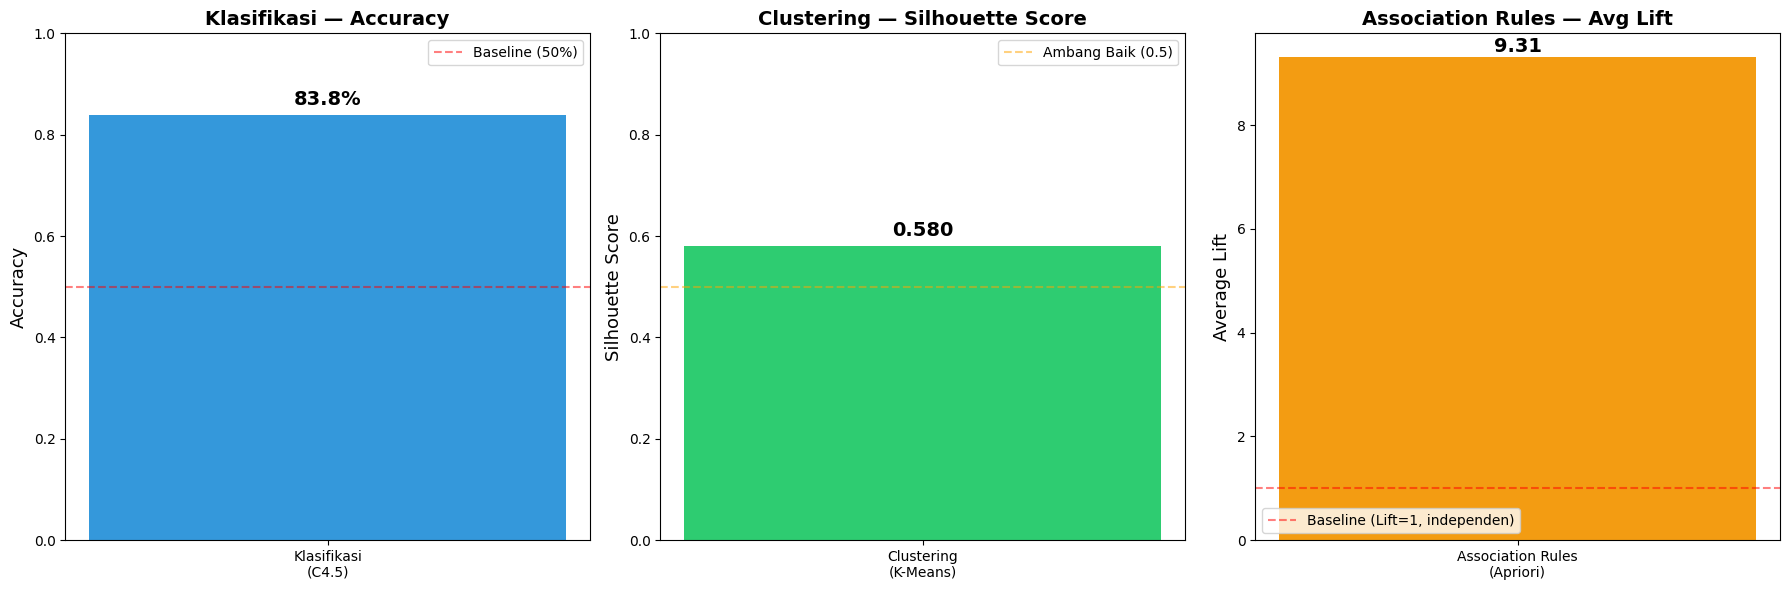

💡 Interpretasi:
   - Klasifikasi akurasi 83.8% → cukup baik memprediksi loyalitas
   - Clustering silhouette 0.580 → kualitas cluster baik
   - Association avg lift 9.31 → hubungan antar produk sangat kuat


In [7]:
# ============================================================
# VISUALISASI PERBANDINGAN: BAR CHART METRIK UTAMA
# ============================================================
# Kita normalisasi nilai metrik ke skala 0-1 agar bisa dibandingkan visual
# Accuracy sudah 0-1, Silhouette 0-1, Lift kita normalisasi juga
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- 1. Accuracy (Klasifikasi) ---
axes[0].bar(['Klasifikasi\n(C4.5)'], [akurasi_dt], color='#3498db', width=0.5)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Accuracy', fontsize=13)
axes[0].set_title('Klasifikasi — Accuracy', fontsize=14, fontweight='bold')
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Baseline (50%)')
axes[0].legend()
axes[0].text(0, akurasi_dt + 0.02, f'{akurasi_dt*100:.1f}%', ha='center', fontsize=14, fontweight='bold')

# --- 2. Silhouette Score (Clustering) ---
axes[1].bar(['Clustering\n(K-Means)'], [silhouette_final], color='#2ecc71', width=0.5)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('Silhouette Score', fontsize=13)
axes[1].set_title('Clustering — Silhouette Score', fontsize=14, fontweight='bold')
axes[1].axhline(y=0.5, color='orange', linestyle='--', alpha=0.5, label='Ambang Baik (0.5)')
axes[1].legend()
axes[1].text(0, silhouette_final + 0.02, f'{silhouette_final:.3f}', ha='center', fontsize=14, fontweight='bold')

# --- 3. Average Lift (Association Rules) ---
axes[2].bar(['Association Rules\n(Apriori)'], [avg_lift], color='#f39c12', width=0.5)
axes[2].set_ylabel('Average Lift', fontsize=13)
axes[2].set_title('Association Rules — Avg Lift', fontsize=14, fontweight='bold')
axes[2].axhline(y=1, color='red', linestyle='--', alpha=0.5, label='Baseline (Lift=1, independen)')
axes[2].legend()
axes[2].text(0, avg_lift + 0.1, f'{avg_lift:.2f}', ha='center', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("💡 Interpretasi:")
print(f"   - Klasifikasi akurasi {akurasi_dt*100:.1f}% → cukup baik memprediksi loyalitas")
print(f"   - Clustering silhouette {silhouette_final:.3f} → kualitas cluster {'baik' if silhouette_final > 0.5 else 'cukup'}")
print(f"   - Association avg lift {avg_lift:.2f} → hubungan antar produk {'sangat kuat' if avg_lift > 3 else 'kuat' if avg_lift > 1.5 else 'lemah'}")

In [8]:
# ============================================================
# TABEL RINGKASAN: KAPAN MENGGUNAKAN METODE TERTENTU?
# ============================================================
# Panduan praktis: setiap metode cocok untuk masalah yang berbeda
# ============================================================

print("=" * 90)
print("📋 PANDUAN: KAPAN MENGGUNAKAN METODE TERTENTU?")
print("=" * 90)
print()
print("┌─────────────────────┬──────────────────────────┬───────────────────────────────────────┐")
print("│ Metode              │ Tujuan                   │ Contoh Penggunaan UMKM Mebel Jepara   │")
print("├─────────────────────┼──────────────────────────┼───────────────────────────────────────┤")
print("│ Klasifikasi (C4.5)  │ Memprediksi label/kelas  │ Prediksi pelanggan loyal vs tidak     │")
print("│                     │ (supervised)             │ loyal → program membership            │")
print("├─────────────────────┼──────────────────────────┼───────────────────────────────────────┤")
print("│ Clustering (K-Means)│ Mengelompokkan data      │ Segmentasi pelanggan: premium,        │")
print("│                     │ (unsupervised)           │ reguler, pasif → strategi berbeda     │")
print("├─────────────────────┼──────────────────────────┼───────────────────────────────────────┤")
print("│ Association Rules   │ Menemukan pola hubungan  │ Bundling produk, layout toko,          │")
print("│ (Apriori)           │ antar item (unsupervised)│ rekomendasi cross-selling             │")
print("└─────────────────────┴──────────────────────────┴───────────────────────────────────────┘")
print()
print("💡 KESIMPULAN: Ketiga metode SALING MELENGKAPI, bukan bersaing!")
print("   - Klasifikasi → JAWABAN: 'Pelanggan ini loyal atau tidak?'")
print("   - Clustering  → JAWABAN: 'Segmen mana pelanggan ini masuk?'")
print("   - Association → JAWABAN: 'Produk apa yang sering dibeli bersamaan?'")

📋 PANDUAN: KAPAN MENGGUNAKAN METODE TERTENTU?

┌─────────────────────┬──────────────────────────┬───────────────────────────────────────┐
│ Metode              │ Tujuan                   │ Contoh Penggunaan UMKM Mebel Jepara   │
├─────────────────────┼──────────────────────────┼───────────────────────────────────────┤
│ Klasifikasi (C4.5)  │ Memprediksi label/kelas  │ Prediksi pelanggan loyal vs tidak     │
│                     │ (supervised)             │ loyal → program membership            │
├─────────────────────┼──────────────────────────┼───────────────────────────────────────┤
│ Clustering (K-Means)│ Mengelompokkan data      │ Segmentasi pelanggan: premium,        │
│                     │ (unsupervised)           │ reguler, pasif → strategi berbeda     │
├─────────────────────┼──────────────────────────┼───────────────────────────────────────┤
│ Association Rules   │ Menemukan pola hubungan  │ Bundling produk, layout toko,          │
│ (Apriori)           │ antar item (unsupe

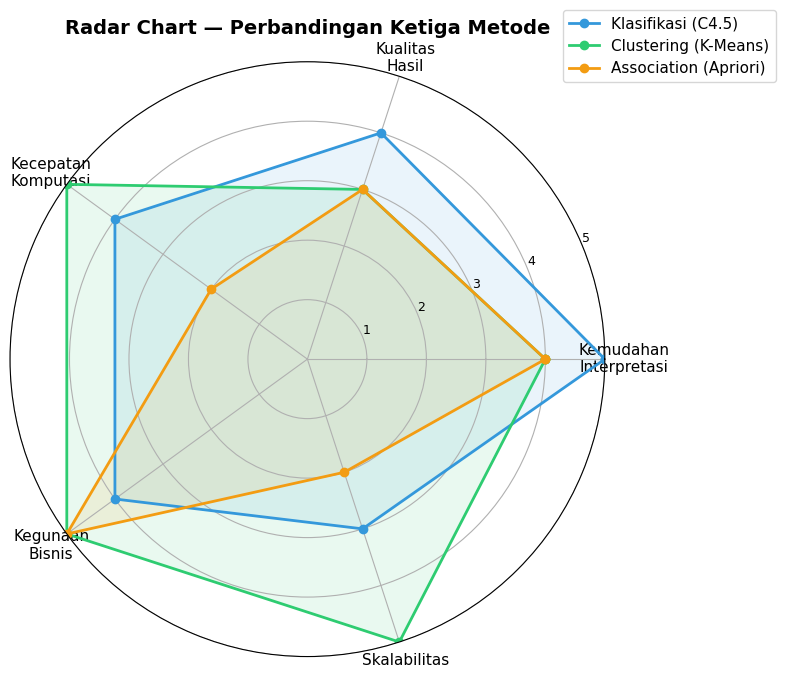

💡 Radar chart menunjukkan kekuatan relatif tiap metode pada berbagai aspek.
   Tidak ada metode yang 'terbaik' di semua aspek — pilih sesuai kebutuhan!


In [9]:
# ============================================================
# VISUALISASI RINGKASAN: RADAR CHART PERBANDINGAN METODE
# ============================================================
# Radar chart menunjukkan kekuatan tiap metode pada beberapa aspek:
#   - Kemudahan Interpretasi (1-5)
#   - Akurasi/Kualitas Hasil (1-5)
#   - Kecepatan Komputasi (1-5)
#   - Kegunaan untuk Bisnis (1-5)
#   - Skalabilitas (1-5)
# ============================================================

# Penilaian subjektif berdasarkan karakteristik metode (skala 1-5)
categories = ['Kemudahan\nInterpretasi', 'Kualitas\nHasil', 'Kecepatan\nKomputasi',
              'Kegunaan\nBisnis', 'Skalabilitas']

# Skor tiap metode (berdasarkan teori dan praktik)
scores = {
    'Klasifikasi (C4.5)':      [5, 4, 4, 4, 3],  # Mudah interpretasi (pohon visual)
    'Clustering (K-Means)':    [4, 3, 5, 5, 5],   # Cepat & scalable
    'Association (Apriori)':   [4, 3, 2, 5, 2],   # Sangat berguna bisnis, tapi lambat di data besar
}

# Buat radar chart
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]  # Tutup lingkaran

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

colors_radar = ['#3498db', '#2ecc71', '#f39c12']
for (method, score), color in zip(scores.items(), colors_radar):
    values = score + score[:1]  # Tutup lingkaran
    ax.plot(angles, values, 'o-', linewidth=2, label=method, color=color)
    ax.fill(angles, values, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['1', '2', '3', '4', '5'], fontsize=9)
ax.set_title('Radar Chart — Perbandingan Ketiga Metode', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)

plt.tight_layout()
plt.show()

print("💡 Radar chart menunjukkan kekuatan relatif tiap metode pada berbagai aspek.")
print("   Tidak ada metode yang 'terbaik' di semua aspek — pilih sesuai kebutuhan!")

In [10]:
# ============================================================
# KESIMPULAN AKHIR & REKOMENDASI KOMPREHENSIF
# ============================================================

print("=" * 70)
print("🏆 KESIMPULAN AKHIR — PROYEK DATA MINING")
print("=" * 70)
print()
print("1. PREPROCESSING (Video 1):")
print(f"   - Data awal: 525.461 baris → Data bersih: {len(df):,} baris")
print("   - Masalah ditangani: missing value, duplikat, pembatalan, outlier")
print("   - Data sudah VALID dan AMANAH (sesuai rubrik)")
print()
print("2. KLASIFIKASI C4.5 (Video 2):")
print(f"   - Akurasi: {akurasi_dt*100:.2f}%")
print("   - Mampu memprediksi loyalitas pelanggan")
print("   - Rekomendasi: program membership & targeted promo")
print()
print("3. CLUSTERING K-MEANS (Video 3):")
print(f"   - K optimal: {best_k} cluster")
print(f"   - Silhouette Score: {silhouette_final:.4f}")
print("   - Segmentasi: Premium / Reguler / Pasif")
print("   - Rekomendasi: strategi berbeda per segmen pelanggan")
print()
print("4. ASSOCIATION RULES APRIORI (Video 4):")
print(f"   - {len(strong_rules)} aturan kuat ditemukan")
print(f"   - Rata-rata Lift: {avg_lift:.2f} (hubungan positif)")
print("   - Rekomendasi: bundling produk, layout toko, cross-selling")
print()
print("5. REKOMENDASI KOMPREHENSIF UNTUK UMKM MEBEL JEPARA:")
print("   a) Gunakan KLASIFIKASI untuk mengidentifikasi pelanggan loyal")
print("   b) Gunakan CLUSTERING untuk menyusun strategi per segmen")
print("   c) Gunakan ASSOCIATION RULES untuk bundling & rekomendasi produk")
print("   d) Terapkan ketiga metode secara BERGANTIAN sesuai kebutuhan bisnis")
print("   e) Update model secara berkala saat data baru tersedia")
print()
print("=" * 70)
print("✅ PROYEK DATA MINING SELESAI!")
print("=" * 70)

🏆 KESIMPULAN AKHIR — PROYEK DATA MINING

1. PREPROCESSING (Video 1):
   - Data awal: 525.461 baris → Data bersih: 342,273 baris
   - Masalah ditangani: missing value, duplikat, pembatalan, outlier
   - Data sudah VALID dan AMANAH (sesuai rubrik)

2. KLASIFIKASI C4.5 (Video 2):
   - Akurasi: 83.82%
   - Mampu memprediksi loyalitas pelanggan
   - Rekomendasi: program membership & targeted promo

3. CLUSTERING K-MEANS (Video 3):
   - K optimal: 4 cluster
   - Silhouette Score: 0.5805
   - Segmentasi: Premium / Reguler / Pasif
   - Rekomendasi: strategi berbeda per segmen pelanggan

4. ASSOCIATION RULES APRIORI (Video 4):
   - 17 aturan kuat ditemukan
   - Rata-rata Lift: 9.31 (hubungan positif)
   - Rekomendasi: bundling produk, layout toko, cross-selling

5. REKOMENDASI KOMPREHENSIF UNTUK UMKM MEBEL JEPARA:
   a) Gunakan KLASIFIKASI untuk mengidentifikasi pelanggan loyal
   b) Gunakan CLUSTERING untuk menyusun strategi per segmen
   c) Gunakan ASSOCIATION RULES untuk bundling & rekomenda